<a href="https://colab.research.google.com/github/AnabelGP/An-lisis-estad-stico-b-sico/blob/main/Whiplash_USAL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análisis clínico: whiplash en TRHB

**Nombre:** Anabel Gallego Pérez

**Fecha:** 07/04/2026

**Versión Python:** 3.14.3

**Contacto:** anabelgallego.fisioterapeuta@gmail.com

**Descripción:** Análisis estadístico de la recuperación de lesionados diagnosticos con latigazo cervical tras las rehabilitación. La tabla da información de ejercicios, días de inicio de terapia, cuestionarios clínicos previos al accidente y posteriores a este, donde se valora dolor con EVA, discapacidad cervica con "Neck Disability Indes" (NDI) y "Whiplash Disability Questionnaire" (WDQ).

## Librerías

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from scipy.stats import norm

## Datos generales texto

In [ ]:
# Parámetros de matplotlib
plt.rcParams.update({'font.size': 12, 'font.family':'Times New Roman'})

## Importación de datos y análisis exploratorio

In [ ]:
# Importamos la base de datos csv
df = pd.read_csv("whiplash.csv", sep = ";")
# Eliminamos la columna ID
df = df.drop("ID", axis = 1)
# Obtenemos los 5 primeros datos de la base
df.head()

,patologias,edad,genero,fecha registro paciente,inicio tto,final tto,fecha primer ej. hecho,fecha ultimo ej. hecho,ej realizados,ej asignados,...,NDI_dias entre form.,NDI_fecha primer form.,NDI_fecha ultimo form.,NDI_punt. primer form.,NDI_punt. ultimo form.,WDQ_dias entre form.,WDQ_fecha primer form.,WDQ_fecha ultimo form.,WDQ_punt. primer form.,WDQ_punt. ultimo form.
0,whiplash,24,female,07/04/2025,08/04/2025,13/04/2025,08/04/2025,08/04/2025,4,8,...,NaN,07/04/2025,NaN,54,NaN,NaN,07/04/2025,NaN,106.0,NaN
1,whiplash,42,male,17/05/2024,17/05/2024,30/05/2024,17/05/2024,22/05/2024,20,56,...,NaN,NaN,NaN,NaN,NaN,NaN,17/05/2024,NaN,98.0,NaN
2,whiplash,28,female,22/07/2024,23/07/2024,04/08/2024,23/07/2024,04/08/2024,57,57,...,13.0,22/07/2024,04/08/2024,70,58,13.0,22/07/2024,04/08/2024,109.0,94.0
3,whiplash,24,female,18/06/2024,18/06/2024,24/06/2024,18/06/2024,24/06/2024,27,27,...,NaN,NaN,NaN,NaN,NaN,6.0,18/06/2024,24/06/2024,51.0,46.0
4,whiplash,20,female,31/07/2024,01/08/2024,01/09/2024,01/08/2024,30/08/2024,55,70,...,36.0,31/07/2024,05/09/2024,70,70,36.0,31/07/2024,05/09/2024,114.0,109.0


In [ ]:
# Información general de la base de datos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 535 entries, 0 to 534
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   patologias               535 non-null    str    
 1   edad                     535 non-null    int64  
 2   genero                   535 non-null    str    
 3   fecha registro paciente  535 non-null    str    
 4   inicio tto               535 non-null    str    
 5   final tto                535 non-null    str    
 6   fecha primer ej. hecho   535 non-null    str    
 7   fecha ultimo ej. hecho   535 non-null    str    
 8   ej realizados            535 non-null    int64  
 9   ej asignados             535 non-null    int64  
 10  sesiones realizadas      535 non-null    int64  
 11  sesiones asignadas       535 non-null    int64  
 12  duracion tto             535 non-null    int64  
 13  ej por sesion            535 non-null    str    
 14  EVA_dias entre form.     407 non-null

No identifica las variables "NDI_punt. primer form." y "NDI_punt. ultimo form." como float.
Las convertimos en float

In [ ]:
# Conversión de las variables "NDI_punt. primer form." y "NDI_punt. ultimo form." en float

df["NDI_punt. primer form."] = pd.to_numeric(
    df["NDI_punt. primer form."], errors="coerce"
)

df["NDI_punt. ultimo form."] = pd.to_numeric(
    df["NDI_punt. ultimo form."], errors="coerce"
)

In [ ]:
# Análisis descriptivo general de las variables numéricas
df.describe()

,edad,ej realizados,ej asignados,sesiones realizadas,sesiones asignadas,duracion tto,EVA_dias entre form.,EVA_punt. primer form.,EVA_punt. ultimo form.,NDI_dias entre form.,NDI_punt. primer form.,NDI_punt. ultimo form.,WDQ_dias entre form.,WDQ_punt. primer form.,WDQ_punt. ultimo form.
count,535.000000,535.000000,535.000000,535.000000,535.000000,535.000000,407.000000,521.000000,407.000000,374.000000,460.000000,347.000000,391.000000,513.000000,391.000000
mean,37.158879,38.656075,50.558879,6.514019,8.633645,13.665421,13.724816,6.744722,5.358722,13.524064,43.817391,36.945245,13.823529,78.173489,66.815857
std,12.434058,32.312690,32.138100,4.909603,4.773561,8.047275,8.466855,1.771054,2.533338,8.021299,18.153585,21.383503,8.533317,27.219147,35.116902
min,16.000000,1.000000,2.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000,0.000000
25%,26.000000,15.500000,30.000000,3.000000,5.000000,9.000000,8.000000,6.000000,4.000000,8.000000,30.000000,20.000000,8.000000,60.000000,36.000000
50%,37.000000,30.000000,42.000000,5.000000,8.000000,13.000000,13.000000,7.000000,6.000000,13.000000,44.000000,38.000000,13.000000,83.000000,74.000000
75%,47.000000,55.500000,66.000000,10.000000,12.000000,17.000000,18.000000,8.000000,7.000000,17.000000,56.000000,52.000000,18.000000,98.000000,96.500000
max,68.000000,213.000000,244.000000,28.000000,32.000000,75.000000,74.000000,10.000000,10.000000,74.000000,92.000000,94.000000,74.000000,129.000000,128.000000


Observamos que hay datos perdidos en variables importante, por lo que realizamos un análisis exahustivo de los datos nulos

## Renombrar variables y creación de las variables NDI sobre 50

convertimos la puntuación de la variable NDI a la escala original del test. Esta variable la tenemos sobre 100 puntos, mientras que la original ha de ser sobre 50. Las convertimos a arrays de NumPy

In [ ]:
# Creamos las nuevas variables sobre 50

# Renombramos las variables clínicas
df = df.rename(columns = {'EVA_punt. primer form.':'EVA_inicial',
                          'EVA_punt. ultimo form.': 'EVA_final',
                          'WDQ_punt. primer form.':'WDQ_inicial',
                          'WDQ_punt. ultimo form.': 'WDQ_final',
                          'NDI_punt. primer form.': 'NDI_inicial_100',
                          'NDI_punt. ultimo form.': 'NDI_final_100'})

df['NDI_inicial_50'] = df['NDI_inicial_100']*0.5 # Variable sobre 50 del NDI incial
df['NDI_final_50'] = df['NDI_final_100']*0.5 # Variable sobre 50 del NDI final

# Variables clínicas
variables_clinicas = df[['EVA_inicial', 'EVA_final', 'NDI_inicial_50', 'NDI_final_50', 'WDQ_inicial', 'WDQ_final']]
variables_eva = df[['EVA_inicial', 'EVA_final']]
variables_ndi = df[['NDI_inicial_50', 'NDI_final_50']]
variables_wdq = df[['WDQ_inicial', 'WDQ_final']]

# Variables
eva_inicial = df['EVA_inicial']
eva_final = df['EVA_final']
ndi_inicial = df['NDI_inicial_50']
ndi_final = df['NDI_final_50']
wdq_inicial = df['WDQ_inicial']
wdq_final = df['WDQ_final']
nombre_variables = [eva_inicial, eva_final, ndi_inicial, ndi_final, wdq_inicial, wdq_final]
inferencia_variables = ["EVA", "NDI", "WDQ"]

## Análisis de los datos nulos

In [ ]:
# Análisis de datos nulos
df.isnull().sum() # Contamos la cantidad de datos nulos que hay en cada variable

patologias                   0
edad                         0
genero                       0
fecha registro paciente      0
inicio tto                   0
final tto                    0
fecha primer ej. hecho       0
fecha ultimo ej. hecho       0
ej realizados                0
ej asignados                 0
sesiones realizadas          0
sesiones asignadas           0
duracion tto                 0
ej por sesion                0
EVA_dias entre form.       128
EVA_fecha primer form.      14
EVA_fecha ultimo form.     128
EVA_inicial                 14
EVA_final                  128
NDI_dias entre form.       161
NDI_fecha primer form.      50
NDI_fecha ultimo form.     161
NDI_inicial_100             75
NDI_final_100              188
WDQ_dias entre form.       144
WDQ_fecha primer form.      22
WDQ_fecha ultimo form.     144
WDQ_inicial                 22
WDQ_final                  144
NDI_inicial_50              75
NDI_final_50               188
dtype: int64

Observamos que hay pacientes que no han respondido a los primeros cuestionarios, por lo que son lesionados que no hay realizado la terapia.
1. Eliminamos los lesionados de estas columnas:
   - EVA_fecha primer form.
   - NDI_fecha primer form.
   - WDQ_fecha primer form.
   - NDI_punt. primer form.
2. Volvemos a analizar los datos

In [ ]:
# Eliminamos los lesionados de las 3 columnas
df = df.dropna(subset=['EVA_fecha primer form.', 'NDI_fecha primer form.', 'WDQ_fecha primer form.', 'NDI_inicial_100', 'NDI_final_100', 'EVA_dias entre form.', 'WDQ_dias entre form.'])
# Visualizamos la base de datos nueva
df.head()

,patologias,edad,genero,fecha registro paciente,inicio tto,final tto,fecha primer ej. hecho,fecha ultimo ej. hecho,ej realizados,ej asignados,...,NDI_fecha ultimo form.,NDI_inicial_100,NDI_final_100,WDQ_dias entre form.,WDQ_fecha primer form.,WDQ_fecha ultimo form.,WDQ_inicial,WDQ_final,NDI_inicial_50,NDI_final_50
2,whiplash,28,female,22/07/2024,23/07/2024,04/08/2024,23/07/2024,04/08/2024,57,57,...,04/08/2024,70.0,58.0,13.0,22/07/2024,04/08/2024,109.0,94.0,35.0,29.0
4,whiplash,20,female,31/07/2024,01/08/2024,01/09/2024,01/08/2024,30/08/2024,55,70,...,05/09/2024,70.0,70.0,36.0,31/07/2024,05/09/2024,114.0,109.0,35.0,35.0
5,whiplash,48,female,28/10/2024,29/10/2024,11/11/2024,29/10/2024,10/11/2024,36,42,...,04/11/2024,26.0,28.0,7.0,28/10/2024,04/11/2024,48.0,36.0,13.0,14.0
6,whiplash,26,female,12/07/2024,12/07/2024,26/07/2024,12/07/2024,26/07/2024,84,90,...,26/07/2024,48.0,40.0,14.0,12/07/2024,26/07/2024,86.0,91.0,24.0,20.0
7,whiplash,30,male,02/10/2025,22/10/2025,05/11/2025,22/10/2025,04/11/2025,60,66,...,31/10/2025,50.0,40.0,9.0,22/10/2025,31/10/2025,86.0,78.0,25.0,20.0


In [ ]:
# Volvemos a analizar los datos nulos
df.isnull().sum()

patologias                 0
edad                       0
genero                     0
fecha registro paciente    0
inicio tto                 0
final tto                  0
fecha primer ej. hecho     0
fecha ultimo ej. hecho     0
ej realizados              0
ej asignados               0
sesiones realizadas        0
sesiones asignadas         0
duracion tto               0
ej por sesion              0
EVA_dias entre form.       0
EVA_fecha primer form.     0
EVA_fecha ultimo form.     0
EVA_inicial                0
EVA_final                  0
NDI_dias entre form.       0
NDI_fecha primer form.     0
NDI_fecha ultimo form.     0
NDI_inicial_100            0
NDI_final_100              0
WDQ_dias entre form.       0
WDQ_fecha primer form.     0
WDQ_fecha ultimo form.     0
WDQ_inicial                0
WDQ_final                  0
NDI_inicial_50             0
NDI_final_50               0
dtype: int64

Tras la eliminación de los datos, volvemos a realizar un análisis descriptivo general de las variables cuantitativas

In [ ]:
# Análisis descriptivo general de las variables cuantitativas sin datos nulos
df.describe().round(2) # Redondeamos a la 2 cifra decimal

,edad,ej realizados,ej asignados,sesiones realizadas,sesiones asignadas,duracion tto,EVA_dias entre form.,EVA_inicial,EVA_final,NDI_dias entre form.,NDI_inicial_100,NDI_final_100,WDQ_dias entre form.,WDQ_inicial,WDQ_final,NDI_inicial_50,NDI_final_50
count,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00,324.00
mean,37.41,46.72,56.76,7.94,9.74,15.13,13.94,6.75,5.27,13.65,43.61,36.33,13.80,76.74,66.02,21.81,18.17
std,12.41,30.79,30.71,4.74,4.64,8.19,8.89,1.81,2.57,8.25,18.72,21.46,8.86,28.43,35.78,9.36,10.73
min,16.00,2.00,6.00,1.00,1.00,1.00,1.00,1.00,0.00,1.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00
25%,26.00,24.00,36.00,4.00,7.00,10.00,8.00,6.00,3.00,8.00,28.00,19.50,7.75,57.00,35.00,14.00,9.75
50%,39.00,42.00,48.00,7.00,9.00,14.00,13.00,7.00,6.00,13.00,44.00,38.00,13.00,83.00,73.50,22.00,19.00
75%,47.00,64.50,72.00,11.00,13.00,18.00,18.00,8.00,7.00,17.00,56.00,52.00,17.25,97.25,96.25,28.00,26.00
max,64.00,213.00,244.00,28.00,32.00,75.00,74.00,10.00,10.00,74.00,92.00,94.00,74.00,129.00,128.00,46.00,47.00


## Análisis descriptivo de las variables clínicas

In [ ]:
# Análisis descriptivo general de variables clínicas
variables_clinicas.describe().round(2)

,EVA_inicial,EVA_final,NDI_inicial_50,NDI_final_50,WDQ_inicial,WDQ_final
count,521.00,407.00,460.00,347.00,513.00,391.00
mean,6.74,5.36,21.91,18.47,78.17,66.82
std,1.77,2.53,9.08,10.69,27.22,35.12
min,1.00,0.00,0.00,0.00,1.00,0.00
25%,6.00,4.00,15.00,10.00,60.00,36.00
50%,7.00,6.00,22.00,19.00,83.00,74.00
75%,8.00,7.00,28.00,26.00,98.00,96.50
max,10.00,10.00,46.00,47.00,129.00,128.00


### Análisis de normalidad de las variables

**Análisis gráfico de las variables**

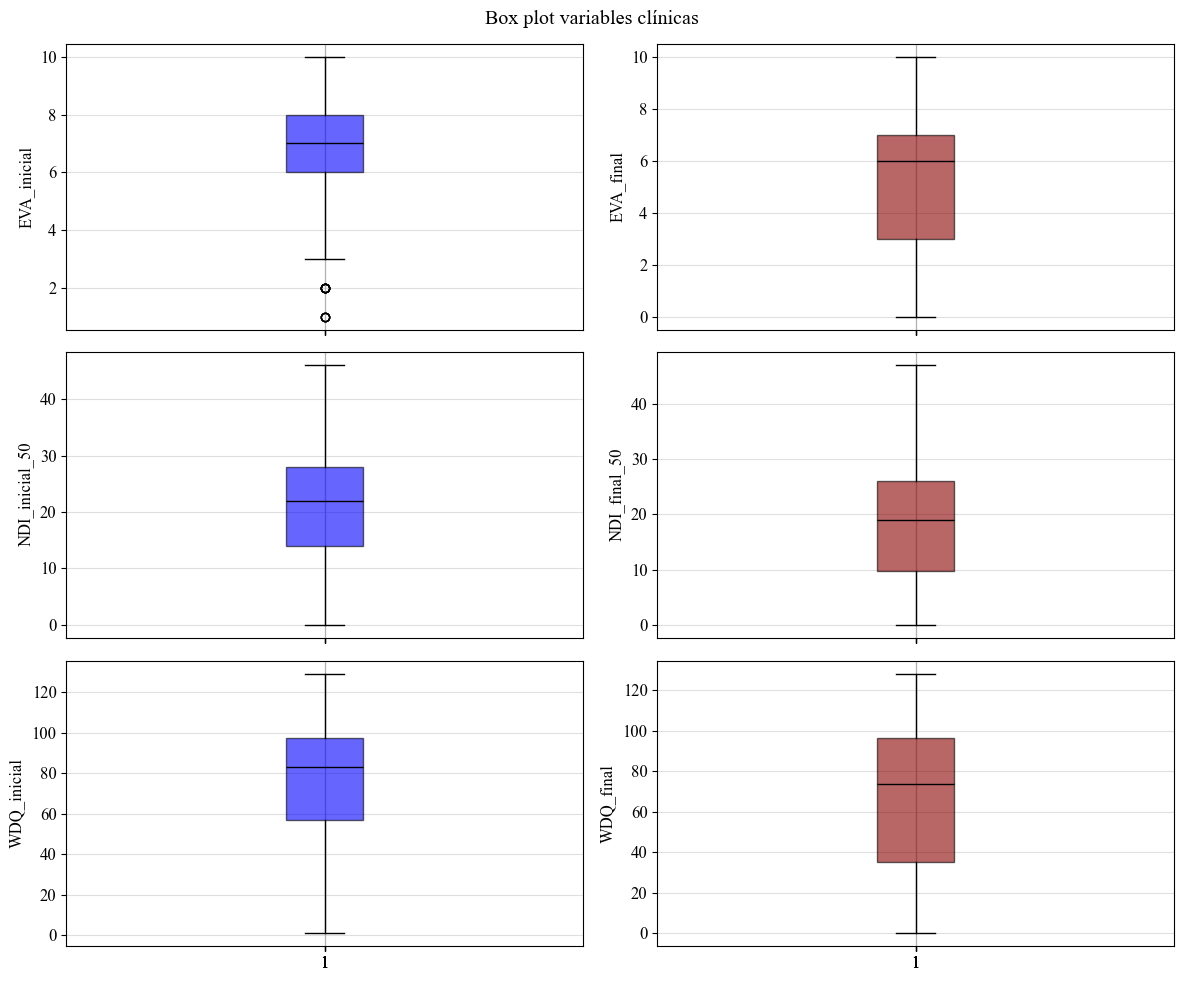

In [ ]:
# Generamos un boxplot de las variables clínicas

#Generamos el gráfico
fig, axes = plt.subplots(3, 2, figsize=(12,10), sharex = True)
axes = axes.flatten() # Convertimos en arrays los gráficos generados
colores = ['blue', 'darkred', 'blue', 'darkred', 'blue', 'darkred']

for i, variable in enumerate(variables_clinicas):
    columna = variables_clinicas
    axes[i].boxplot(df[variable].dropna(), patch_artist=True, boxprops = dict(facecolor=colores[i], alpha=0.6), medianprops=dict(color='black'), )
    axes[i].set_ylabel(variable)
    axes[i].grid(True, alpha = 0.4)

fig.suptitle("Box plot variables clínicas")
plt.tight_layout()
plt.savefig("Box plot variables clinicas.png", dpi = 300, bbox_inches = "tight")
plt.show()


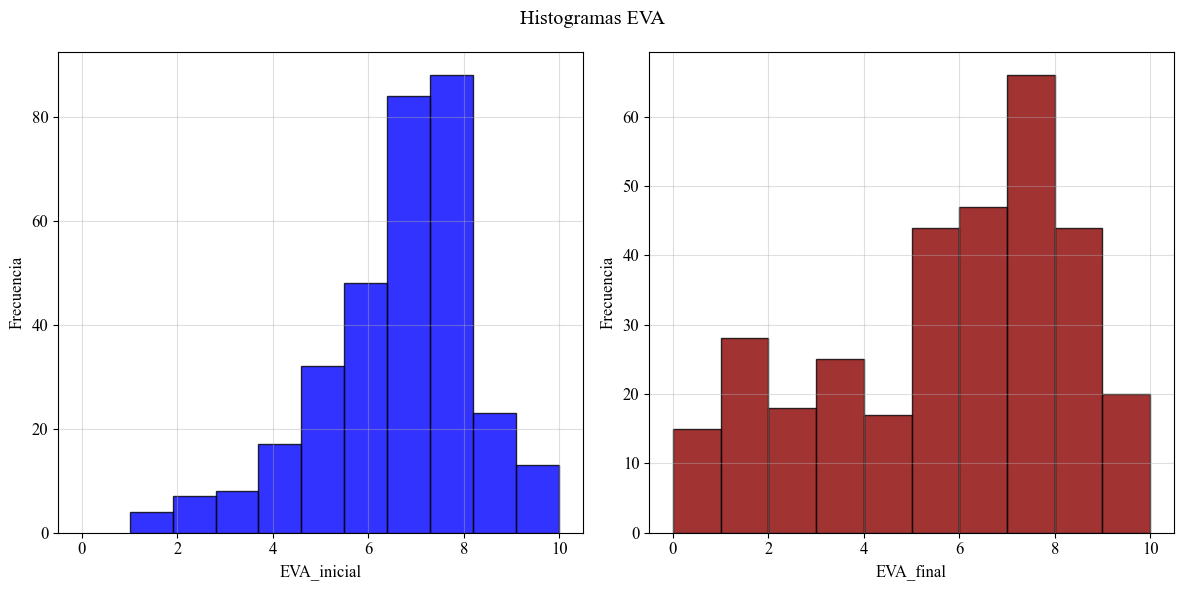

In [ ]:
# Generamos histogrmas de las variables eva

# Creamos el gráfico
fig, axes = plt.subplots(1, 2, figsize=(12,6), sharex = True)
axes = axes.flatten() # Convertimos en arrays los gráficos generados
colores = ['blue', 'darkred']

for i, variable in enumerate(variables_eva):
    columna = variables_clinicas
    axes[i].hist(df[variable].dropna(), bins = 10, color = colores[i], alpha = 0.8, edgecolor = "black")
    axes[i].set_ylabel("Frecuencia")
    axes[i].set_xlabel(variable)
    axes[i].grid(True, alpha = 0.4)

fig.suptitle("Histogramas EVA")
plt.tight_layout()
plt.savefig("Histograma variables EVA.png", dpi = 300, bbox_inches = "tight")
plt.show()

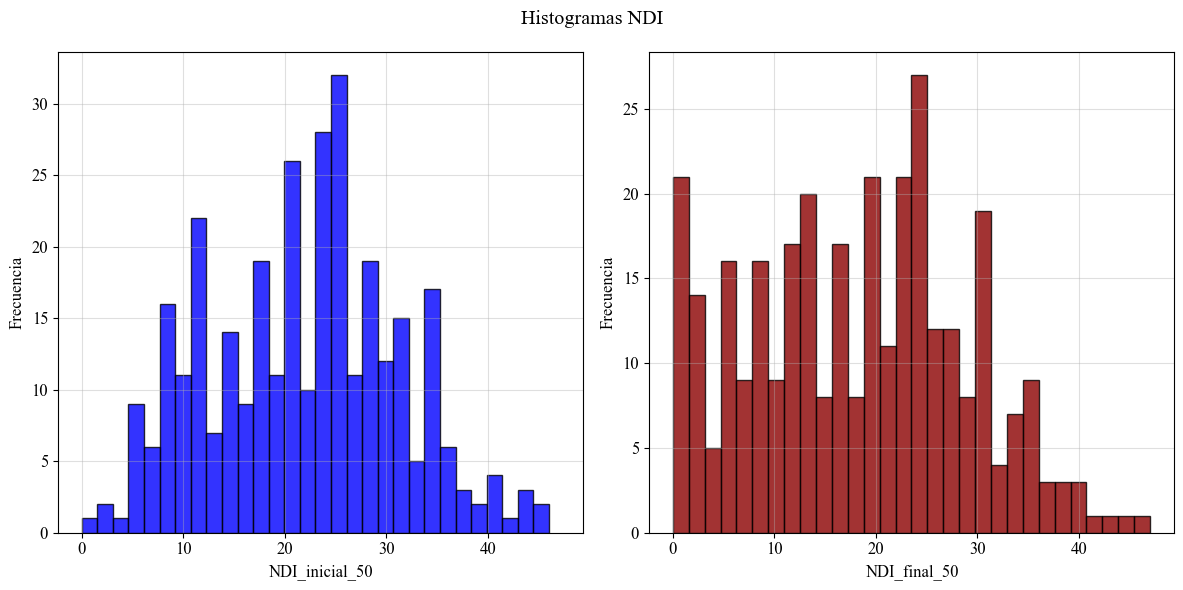

In [ ]:
# Generamos histogrmas de las variables NDI

# Generamos el gráfico
fig, axes = plt.subplots(1, 2, figsize=(12,6), sharex = True)
axes = axes.flatten() # Convertimos en arrays los gráficos generados
colores = ['blue', 'darkred']

for i, variable in enumerate(variables_ndi):
    columna = variables_clinicas
    axes[i].hist(df[variable].dropna(), bins = 30, color = colores[i], alpha = 0.8, edgecolor = "black")
    axes[i].set_ylabel("Frecuencia")
    axes[i].set_xlabel(variable)
    axes[i].grid(True, alpha = 0.4)

fig.suptitle("Histogramas NDI")
plt.tight_layout()
plt.savefig("Histograma variables NDI.png", dpi = 300, bbox_inches = "tight")
plt.show()

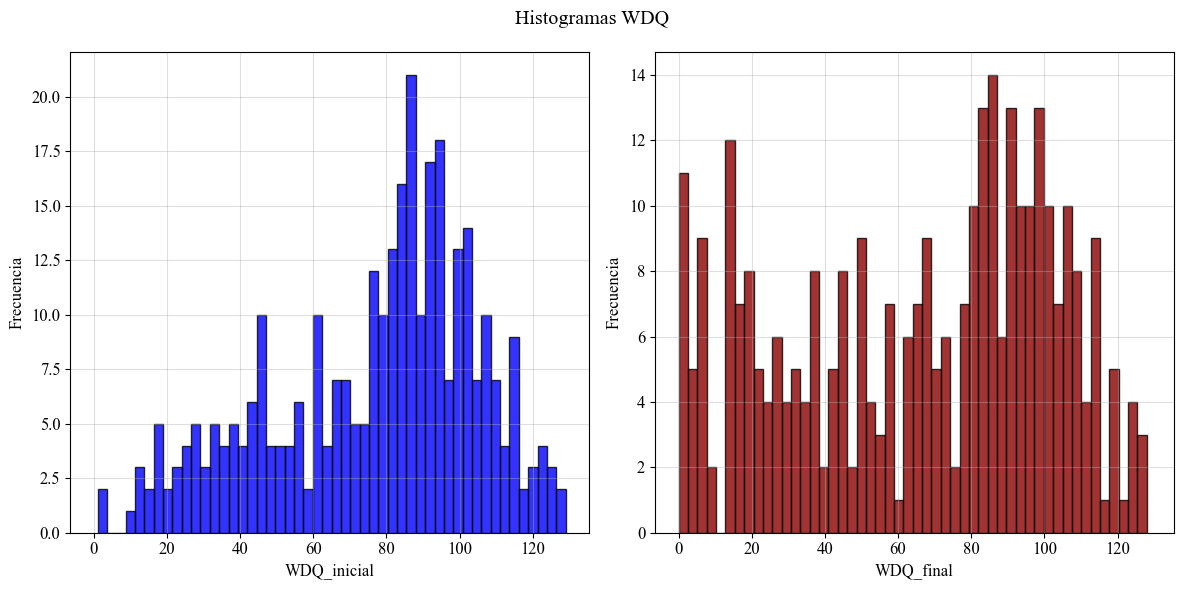

In [ ]:
# Generamos histogrmas de las variables WDQ

# Generamos el gráfico
fig, axes = plt.subplots(1, 2, figsize=(12,6), sharex = True)
axes = axes.flatten() # Convertimos en arrays los gráficos generados
colores = ['blue', 'darkred']

for i, variable in enumerate(variables_wdq):
    columna = variables_clinicas
    axes[i].hist(df[variable].dropna(), bins = 50, color = colores[i], alpha = 0.8, edgecolor = "black")
    axes[i].set_ylabel("Frecuencia")
    axes[i].set_xlabel(variable)
    axes[i].grid(True, alpha = 0.4)

fig.suptitle("Histogramas WDQ")
plt.tight_layout()
plt.savefig("Histograma variables WDQ.png", dpi = 300, bbox_inches = "tight")
plt.show()

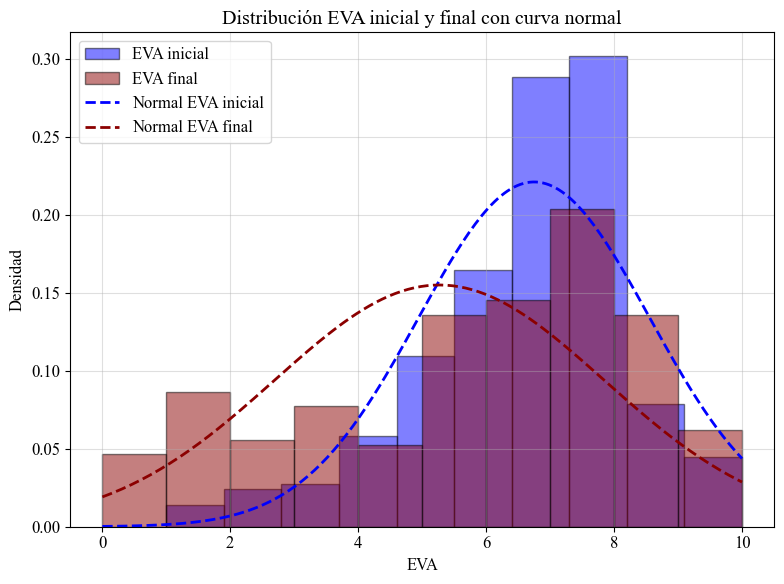

In [ ]:
# Histogramas de EVA superpuestos

# Creamos el gráfico
fig, ax = plt.subplots(figsize=(8, 6))
# Datos
eva_ini = df["EVA_inicial"].dropna()
eva_fin = df["EVA_final"].dropna()
# Histogramas (densidad)
ax.hist(eva_ini, bins=10, density=True, alpha=0.5, color="blue", edgecolor="black", label="EVA inicial")
ax.hist(eva_fin, bins=10, density=True, alpha=0.5, color="darkred", edgecolor="black", label="EVA final")
# Rango común para las curvas
x = np.linspace(0, 10, 200) # Establecemos el rango de 0 a 10 como la escala EVA y calculamos la curva de normalidad en 200 puntos
# Curvas de normalidad
ax.plot(x, norm.pdf(x, eva_ini.mean(), eva_ini.std()), color="blue", linewidth=2, linestyle="--", label="Normal EVA inicial") # Generamos la curva de normalidad con la media y la SD
ax.plot(x, norm.pdf(x, eva_fin.mean(), eva_fin.std()), color="darkred", linewidth=2, linestyle="--", label="Normal EVA final") # Generamos la curva de normalidad con la media y la SD
# Estética
ax.set_xlabel("EVA")
ax.set_ylabel("Densidad")
ax.set_title("Distribución EVA inicial y final con curva normal")
ax.grid(True, alpha=0.4)
ax.legend()
plt.tight_layout()
plt.savefig("Histograma variables EVA superpuestos.png", dpi = 300, bbox_inches = "tight")
plt.show()

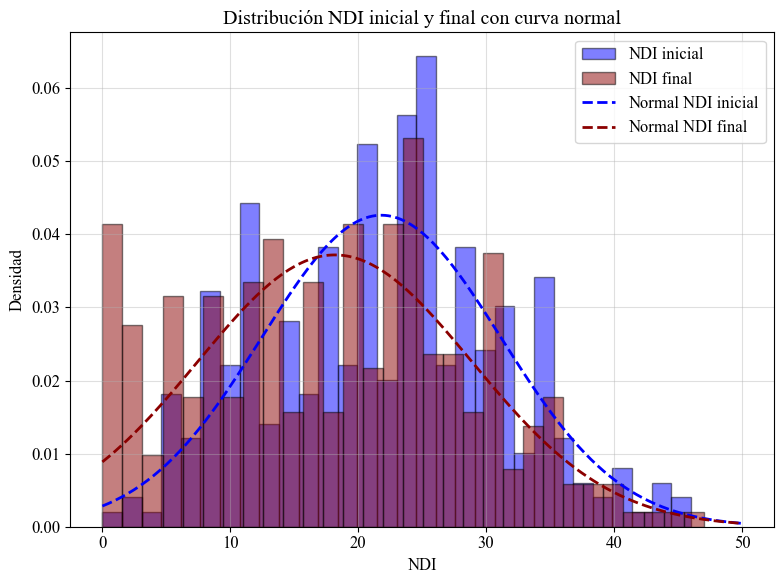

In [ ]:
# Histogramas de NDI superpuestos

# Creamos el gráfico
fig, ax = plt.subplots(figsize=(8, 6))
# Datos
ndi_ini = df["NDI_inicial_50"].dropna()
ndi_fin = df["NDI_final_50"].dropna()
# Histogramas (densidad)
ax.hist(ndi_ini, bins=30, density=True, alpha=0.5, color="blue", edgecolor="black", label="NDI inicial")
ax.hist(ndi_fin, bins=30, density=True, alpha=0.5, color="darkred", edgecolor="black", label="NDI final")
# Rango común para las curvas
x = np.linspace(0, 50, 200) # Establecemos el rango de 0 a 50 como la escala EVA y calculamos la curva de normalidad en 200 puntos
# Curvas de normalidad
ax.plot(x, norm.pdf(x, ndi_ini.mean(), ndi_ini.std()), color="blue", linewidth=2, linestyle="--", label="Normal NDI inicial") # Generamos la curva de normalidad con la media y la SD
ax.plot(x, norm.pdf(x, ndi_fin.mean(), ndi_fin.std()), color="darkred", linewidth=2, linestyle="--", label="Normal NDI final") # Generamos la curva de normalidad con la media y la SD
# Estética
ax.set_xlabel("NDI")
ax.set_ylabel("Densidad")
ax.set_title("Distribución NDI inicial y final con curva normal")
ax.grid(True, alpha=0.4)
ax.legend()
plt.tight_layout()
plt.savefig("Histograma variables NDI superpuestos.png", dpi = 300, bbox_inches = "tight")
plt.show()

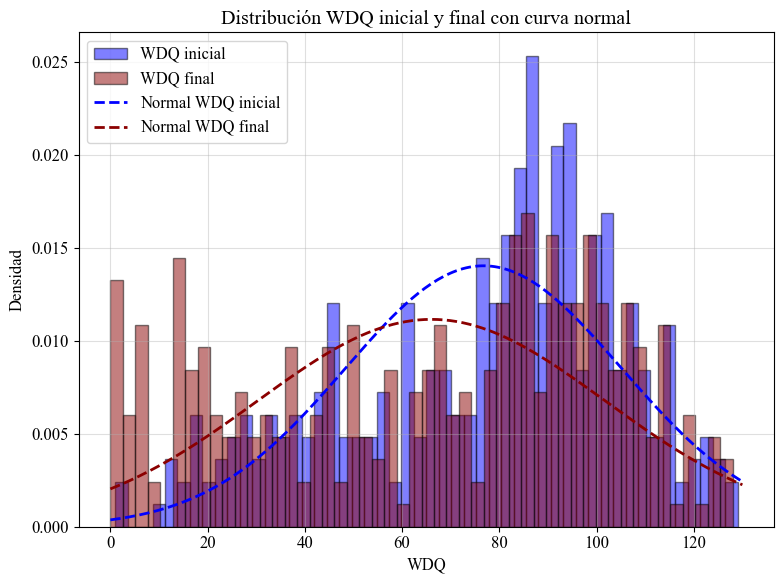

In [ ]:
# Histogramas de WDQ superpuestos

# Creamos el gráfico
fig, ax = plt.subplots(figsize=(8, 6))
# Datos
wdq_ini = df["WDQ_inicial"].dropna()
wdq_fin = df["WDQ_final"].dropna()
# Histogramas (densidad)
ax.hist(wdq_ini, bins=50, density=True, alpha=0.5, color="blue", edgecolor="black", label="WDQ inicial")
ax.hist(wdq_fin, bins=50, density=True, alpha=0.5, color="darkred", edgecolor="black", label="WDQ final")
# Rango común para las curvas
x = np.linspace(0, 130, 200) # Establecemos el rango de 0 a 130 como la escala EVA y calculamos la curva de normalidad en 200 puntos
# Curvas de normalidad
ax.plot(x, norm.pdf(x, wdq_ini.mean(), wdq_ini.std()), color="blue", linewidth=2, linestyle="--", label="Normal WDQ inicial") # Generamos la curva de normalidad con la media y la SD
ax.plot(x, norm.pdf(x, wdq_fin.mean(), wdq_fin.std()), color="darkred", linewidth=2, linestyle="--", label="Normal WDQ final") # Generamos la curva de normalidad con la media y la SD
# Estética
ax.set_xlabel("WDQ")
ax.set_ylabel("Densidad")
ax.set_title("Distribución WDQ inicial y final con curva normal")
ax.grid(True, alpha=0.4)
ax.legend()
plt.tight_layout()
plt.savefig("Histograma variables WDQ superpuestos.png", dpi = 300, bbox_inches = "tight")
plt.show()

**Conclusiones:** Podemos observar que a simple vista estamos ante variables que no van a seguir una distribución normal, salvo la EVA inicial que parece que puede tener distribución normal.
    Además, podemos observar que es probable que no haya diferencia clínica entre el antes y el después de los lesionados

### Análisis de normalidad de las variables clínicas

**Prueba Kolmogorov-Smirnov**

In [ ]:
# Pruebas de normalidad para las variables clínicas

# Prueba de Kolmogorov-Smirnov
# H0--> Los datos tienen una distribución normal
# H1--> Los datos no tienen una distribución normal

# Prueba de KS
estadisticos_ks = []
p_valores_ks = []
for variable in nombre_variables:
    stat, p_valor = stats.kstest(variable, "norm")
    stat_ks_variable, p_valor_ks_variable = stat, p_valor
    estadisticos_ks.append(stat_ks_variable)
    p_valores_ks.append(p_valor_ks_variable)

# Estado
estado_ks = "No normal" if p_valores_ks[i] < 0.05 else "Normal"

# Informe
print("Variables clínicas\n")
for i, nombre in enumerate (variables_clinicas):
    print(f'Variable {nombre}')
    print(f'Estadístico KS: {estadisticos_ks[i]}')
    print(f'P valor: {p_valores_ks[i]}')
    print(f'Conclusión: {estado_ks}\n')

Variables clínicas

Variable EVA_inicial
Estadístico KS: nan
P valor: nan
Conclusión: Normal

Variable EVA_final
Estadístico KS: nan
P valor: nan
Conclusión: Normal

Variable NDI_inicial_50
Estadístico KS: nan
P valor: nan
Conclusión: Normal

Variable NDI_final_50
Estadístico KS: nan
P valor: nan
Conclusión: Normal

Variable WDQ_inicial
Estadístico KS: nan
P valor: nan
Conclusión: Normal

Variable WDQ_final
Estadístico KS: nan
P valor: nan
Conclusión: Normal



**Prueba Shapiro-Wilk**

In [ ]:
# Pruebas de normalidad para las variables clínicas

# Prueba de Shapiro-Wilk
# H0--> Los datos tienen una distribución normal
# H1--> Los datos no tienen una distribución normal

estadisticos_sw = []
p_valores_sw = []
for variable in nombre_variables:
    stat, p_valor = stats.shapiro(variable)
    stat_variable, p_valor_variable = stat, p_valor
    estadisticos_sw.append(stat_variable)
    p_valores_sw.append(p_valor_variable)

# Estado
estado_sw = "No normal" if p_valores_sw[i] < 0.05 else "Normal"

# Informe
print("Variables clínicas\n")
for i, nombre in enumerate (variables_clinicas):
    print(f'Variable {nombre}')
    print(f'Estadístico Shapiro-Wilk: {estadisticos_sw[i]}')
    print(f'P valor: {p_valores_sw[i]}')
    print(f'Conclusión: {estado_sw}\n')

Variables clínicas

Variable EVA_inicial
Estadístico Shapiro-Wilk: nan
P valor: nan
Conclusión: Normal

Variable EVA_final
Estadístico Shapiro-Wilk: nan
P valor: nan
Conclusión: Normal

Variable NDI_inicial_50
Estadístico Shapiro-Wilk: nan
P valor: nan
Conclusión: Normal

Variable NDI_final_50
Estadístico Shapiro-Wilk: nan
P valor: nan
Conclusión: Normal

Variable WDQ_inicial
Estadístico Shapiro-Wilk: nan
P valor: nan
Conclusión: Normal

Variable WDQ_final
Estadístico Shapiro-Wilk: nan
P valor: nan
Conclusión: Normal



**Conclusiones:** Las pruebas de normalidad concluyen que las variables clínicas no siguen una distribución normal, lo que concuerda con lo que hemos observado con los gráficos Box-plot y con los histogramas de estas variables. Por esto, vamos a proceder a hacer el análisis inferencia con las pruebas no paramétricas

## Estadística inferencial

- Queremos establecer si hay diferencias en la clínica de los lesionados después de realizar la terapia.
- Estamos ante variables clínicas que no siguen un distribución normal, por lo que realizaremos pruebas no paramétricas.
- Queremos ver si hay un cambio entre el antes y el después de la terapia, por lo que estamos ante datos de variables relacionadas (Wilcoxon test).
- Solo seleccionaremos a los sujetos que hayan estado más de 7 días en la terapia.

### Selección de la muestra

In [ ]:
# Seleccionamos la muestra con los sujetos que han estado en terapia más de 7 días
df_trabajadores = df[df['duracion tto'] > 6]

# Variables clínicas con la selección anterior
eva_inicial_t = df_trabajadores['EVA_inicial']
eva_final_t = df_trabajadores['EVA_final']
ndi_inicial_t = df_trabajadores['NDI_inicial_50']
ndi_final_t = df_trabajadores['NDI_final_50']
wdq_inicial_t = df['WDQ_inicial']
wdq_final_t = df['WDQ_final']

**Wilcoxon test:** Test no paramétrico para 2 variables relacionadas
- H0: No hay diferencias estadísticamente significativas entre las medianas de las dos variables
- H1: Hay diferencias estadísticamente significativas entre las medianas de las dos variables
- Nivel de significación: 0.05 (5%)

**Wilcoxon test EVA**

In [ ]:
# Test Wilcoxon para la EVA

# Variables --> "EVA_inicial" y "EVA_final"
stat, p_valor = stats.wilcoxon(eva_inicial_t, eva_final_t)
stat_eva, p_valor_eva = stat, p_valor

# Variables --> "NDI_inicial" y "NDI_final"
stat, p_valor = stats.wilcoxon(ndi_inicial_t, ndi_final_t)
stat_ndi, p_valor_ndi = stat, p_valor

# Variables --> "WDQ_inicial" y "WDQ_final"
stat, p_valor = stats.wilcoxon(wdq_inicial_t, wdq_final_t)
stat_wdq, p_valor_wdq = stat, p_valor

# Creación de listas con los estadísticos
stat_wilcoxon = [stat_eva, stat_ndi, stat_wdq]
p_valores_wilcoxon = [p_valor_eva, p_valor_ndi, p_valor_wdq]

# Estado
#estado_wilcoxon = "Significativo" if p_valores_wilcoxon[valor] < 0.05 else "No significativo"

# Informe
print("Variables clínicas\n")
for i, nombre in enumerate (inferencia_variables):
    estado_wilcoxon = ("Significativo" if p_valores_wilcoxon[i] < 0.05 else "No significativo")
    print(f'Variable {nombre}')
    print(f'Estadístico Wilcoxon: {stat_wilcoxon[i]}')
    print(f'P valor: {p_valores_wilcoxon[i]}')
    print(f'Conclusión: {estado_wilcoxon}\n')

Variables clínicas

Variable EVA
Estadístico Wilcoxon: 2502.0
P valor: 1.0009119075457393e-28
Conclusión: Significativo

Variable NDI
Estadístico Wilcoxon: 7831.0
P valor: 5.122062744793206e-19
Conclusión: Significativo

Variable WDQ
Estadístico Wilcoxon: 10194.5
P valor: 7.802862638473104e-19
Conclusión: Significativo



**Conclusión:** Los lesionados salen mejor tras la rehabilitación

### Histogramas de variables clínicas solapados con los datos de los trabajadores

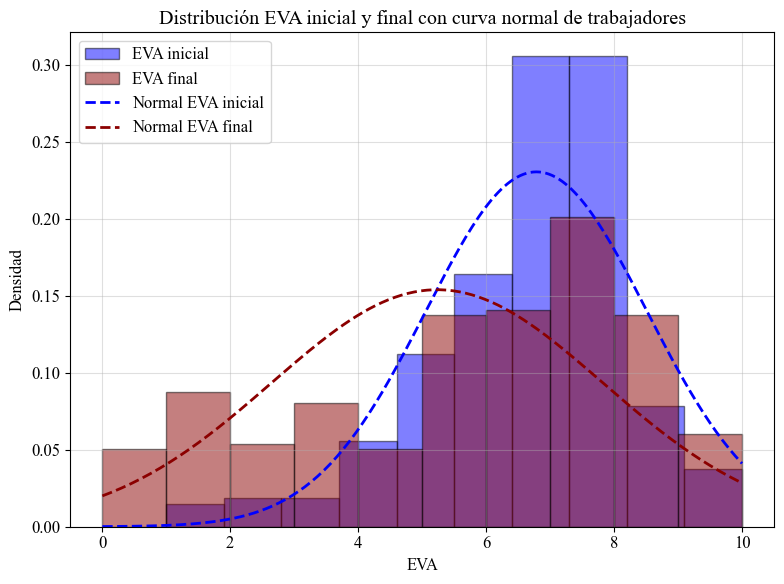

In [ ]:
# Histogramas de EVA superpuestos trabajadores

# Creamos el gráfico
fig, ax = plt.subplots(figsize=(8, 6))
# Histogramas (densidad)
ax.hist(eva_inicial_t, bins=10, density=True, alpha=0.5, color="blue", edgecolor="black", label="EVA inicial")
ax.hist(eva_final_t, bins=10, density=True, alpha=0.5, color="darkred", edgecolor="black", label="EVA final")
# Rango común para las curvas
x = np.linspace(0, 10, 200) # Establecemos el rango de 0 a 10 como la escala EVA y calculamos la curva de normalidad en 200 puntos
# Curvas de normalidad
ax.plot(x, norm.pdf(x, eva_inicial_t.mean(), eva_inicial_t.std()), color="blue", linewidth=2, linestyle="--", label="Normal EVA inicial") # Generamos la curva de normalidad con la media y la SD
ax.plot(x, norm.pdf(x, eva_final_t.mean(), eva_final_t.std()), color="darkred", linewidth=2, linestyle="--", label="Normal EVA final") # Generamos la curva de normalidad con la media y la SD
# Estética
ax.set_xlabel("EVA")
ax.set_ylabel("Densidad")
ax.set_title("Distribución EVA inicial y final con curva normal de trabajadores")
ax.grid(True, alpha=0.4)
ax.legend()
plt.tight_layout()
plt.savefig("Histograma variables EVA superpuestos trabajadores.png", dpi = 300, bbox_inches = "tight")
plt.show()

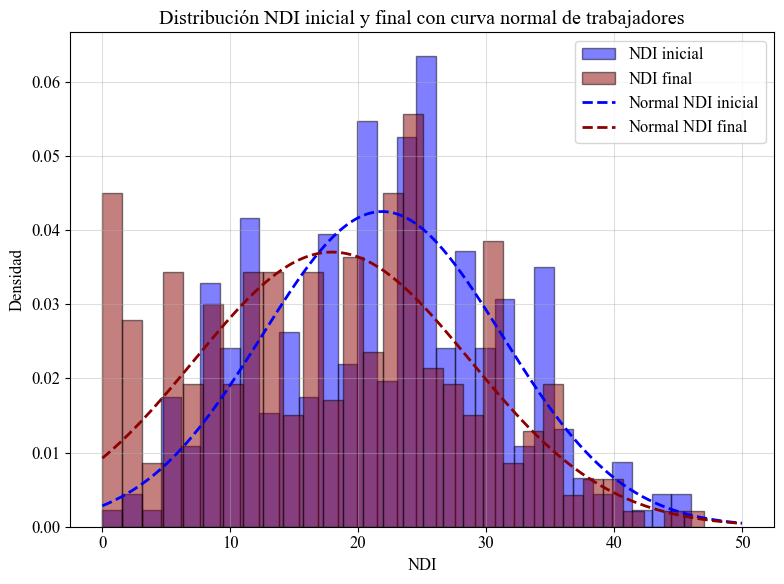

In [ ]:
# Histogramas de NDI superpuestos

# Creamos el gráfico
fig, ax = plt.subplots(figsize=(8, 6))
# Histogramas (densidad)
ax.hist(ndi_inicial_t, bins=30, density=True, alpha=0.5, color="blue", edgecolor="black", label="NDI inicial")
ax.hist(ndi_final_t, bins=30, density=True, alpha=0.5, color="darkred", edgecolor="black", label="NDI final")
# Rango común para las curvas
x = np.linspace(0, 50, 200) # Establecemos el rango de 0 a 50 como la escala EVA y calculamos la curva de normalidad en 200 puntos
# Curvas de normalidad
ax.plot(x, norm.pdf(x, ndi_inicial_t.mean(), ndi_inicial_t.std()), color="blue", linewidth=2, linestyle="--", label="Normal NDI inicial") # Generamos la curva de normalidad con la media y la SD
ax.plot(x, norm.pdf(x, ndi_final_t.mean(), ndi_final_t.std()), color="darkred", linewidth=2, linestyle="--", label="Normal NDI final") # Generamos la curva de normalidad con la media y la SD
# Estética
ax.set_xlabel("NDI")
ax.set_ylabel("Densidad")
ax.set_title("Distribución NDI inicial y final con curva normal de trabajadores")
ax.grid(True, alpha=0.4)
ax.legend()
plt.tight_layout()
plt.savefig("Histograma variables NDI superpuestos trabajadores.png", dpi = 300, bbox_inches = "tight")
plt.show()

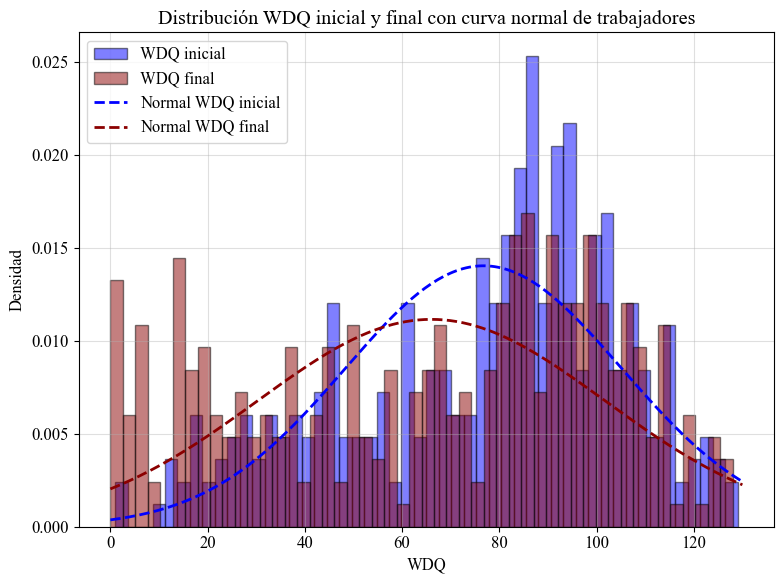

In [ ]:
# Histogramas de WDQ superpuestos

# Creamos el gráfico
fig, ax = plt.subplots(figsize=(8, 6))
# Histogramas (densidad)
ax.hist(wdq_inicial_t, bins=50, density=True, alpha=0.5, color="blue", edgecolor="black", label="WDQ inicial")
ax.hist(wdq_final_t, bins=50, density=True, alpha=0.5, color="darkred", edgecolor="black", label="WDQ final")
# Rango común para las curvas
x = np.linspace(0, 130, 200) # Establecemos el rango de 0 a 130 como la escala EVA y calculamos la curva de normalidad en 200 puntos
# Curvas de normalidad
ax.plot(x, norm.pdf(x, wdq_inicial_t.mean(), wdq_inicial_t.std()), color="blue", linewidth=2, linestyle="--", label="Normal WDQ inicial") # Generamos la curva de normalidad con la media y la SD
ax.plot(x, norm.pdf(x, wdq_final_t.mean(), wdq_final_t.std()), color="darkred", linewidth=2, linestyle="--", label="Normal WDQ final") # Generamos la curva de normalidad con la media y la SD
# Estética
ax.set_xlabel("WDQ")
ax.set_ylabel("Densidad")
ax.set_title("Distribución WDQ inicial y final con curva normal de trabajadores")
ax.grid(True, alpha=0.4)
ax.legend()
plt.tight_layout()
plt.savefig("Histograma variables WDQ superpuestos trabajadores.png", dpi = 300, bbox_inches = "tight")
plt.show()

**Conclusiones:** Apesar de que los test han dado significativos, según lo observado en los gráficos, es muy probable que el poder estadístico sea muy bajo, por lo que concluimos que se debería aumentar el tamaño muestral del estudio y volver a realizar la investigación para poder determinar si estos resultados se confirman o, por el contrario, la terapia no está siendo efectiva